In [1]:
import os
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import faiss
import hnswlib

import joblib
from datasets import load_from_disk
from scipy.sparse import load_npz, csr_matrix
from sklearn.model_selection import train_test_split
from catboost import CatBoostRanker, Pool

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Сформированная матрица взаимодействий для трейна
with open('mappings_item_filters_user_filters.pkl', 'rb') as f:
    mappings = pickle.load(f)

item2id = mappings['item2id']
user2id = mappings['user2id']
id2item = mappings['id2item']
id2user = mappings['id2user']

# Тест
with open('test_true_item_filters_user_filters.pkl', 'rb') as f:
    test_true = pickle.load(f)

user_item_matrix = load_npz('user_item_matrix_item_filters_user_filters.npz')
user_item_csr = user_item_matrix.tocsr()

N_USERS, N_ITEMS_CATALOG = user_item_matrix.shape
print(f'Train users: {N_USERS}')
print(f'Train items: {N_ITEMS_CATALOG}')
print(f'Test users: {len(test_true)}')


Train users: 6477
Train items: 200250
Test users: 4429


In [4]:
embed_ds = load_from_disk('yambda-dataset/check6/yambda_embed')

all_item_ids = np.asarray(embed_ds['item_id'])
train_item_arr = np.fromiter(item2id.keys(), dtype=np.int64, count=len(item2id))

keep_mask = np.isin(all_item_ids, train_item_arr)
keep_idx = np.where(keep_mask)[0].tolist()

embed_ds_filt = embed_ds.select(keep_idx)
embed_df = embed_ds_filt.to_pandas()

EMB_DIM = len(embed_df['embed'].iloc[0])

embed_df['col_idx'] = embed_df['item_id'].map(item2id)
embed_df = embed_df.sort_values('col_idx').reset_index(drop=True)

norm_matrix = np.stack(embed_df['normalized_embed'].values).astype(np.float32)
raw_matrix = np.stack(embed_df['embed'].values).astype(np.float32)
col_idx_arr = embed_df['col_idx'].values.astype(np.int64)

colidx2embrow = {int(c): r for r, c in enumerate(col_idx_arr)}

print(f'raw embed matrix: {raw_matrix.shape}')

Loading dataset from disk:   0%|          | 0/32 [00:00<?, ?it/s]

raw embed matrix: (193607, 128)


## 2. ANN индексы: HNSW и FAISS IVF

Строим **два** индекса (как требует задание):
* `hnswlib.Index(space='cosine')` — primary, используется для отбора кандидатов и при обучении, и при инференсе.
* `faiss.IndexIVFFlat` (METRIC_INNER_PRODUCT на L2-нормированных) — для сравнения.

Метки в HNSW = `col_idx` в `user_item_matrix`, чтобы сразу получать индекс матрицы из соседей.

In [5]:
RESULTS_DIR = 'check6-results'

N_ITEMS = norm_matrix.shape[0]

hnsw_index = hnswlib.Index(space='cosine', dim=EMB_DIM)
hnsw_index.init_index(max_elements=N_ITEMS, ef_construction=200, M=32)

hnsw_index.add_items(norm_matrix, col_idx_arr)

hnsw_index.set_ef(256)
hnsw_index.save_index(f'{RESULTS_DIR}/hnsw_index.bin')

In [5]:
faiss_vectors = norm_matrix.copy()
faiss.normalize_L2(faiss_vectors)

N_CLUSTERS = min(int(np.sqrt(N_ITEMS)) * 4, 4096)

quantizer   = faiss.IndexFlatIP(EMB_DIM)
faiss_index = faiss.IndexIVFFlat(quantizer, EMB_DIM, N_CLUSTERS, faiss.METRIC_INNER_PRODUCT)

t0 = time.time()
faiss_index.train(faiss_vectors)
faiss_index.add(faiss_vectors)
faiss_index.nprobe = 32
build_time_faiss = time.time() - t0
print(f'FAISS IVF built in {build_time_faiss:.1f}s | nlist={N_CLUSTERS}, nprobe=32, total={faiss_index.ntotal:,}')

faiss.write_index(faiss_index, f'{RESULTS_DIR}/faiss_ivf.index')
print(f'FAISS saved → {RESULTS_DIR}/faiss_ivf.index')

FAISS IVF built in 2.4s | nlist=1760, nprobe=32, total=193,607


FAISS saved → ranker-result/faiss_ivf.index


In [6]:
rng = np.random.default_rng(RANDOM_STATE)
n_probe = 200
probe_idx = rng.choice(N_ITEMS, size=n_probe, replace=False)
probe_vecs = norm_matrix[probe_idx]

K_BENCH = 50

t0 = time.time(); hnsw_labels, _ = hnsw_index.knn_query(probe_vecs, k=K_BENCH); t_hnsw = time.time() - t0

probe_faiss = probe_vecs.copy(); faiss.normalize_L2(probe_faiss)
t0 = time.time(); _, faiss_labels = faiss_index.search(probe_faiss, K_BENCH); t_faiss = time.time() - t0
faiss_col_labels = col_idx_arr[faiss_labels]

ann_bench = pd.DataFrame([
    {'index': 'HNSW',      'build_sec': build_time_hnsw,  f'query_sec_x{n_probe}': t_hnsw,  'avg_ms_per_query': t_hnsw  * 1000 / n_probe},
    {'index': 'FAISS_IVF', 'build_sec': build_time_faiss, f'query_sec_x{n_probe}': t_faiss, 'avg_ms_per_query': t_faiss * 1000 / n_probe},
])
print(ann_bench.to_string(index=False))
ann_bench.to_csv(f'{RESULTS_DIR}/ann_benchmark.csv', index=False)

overlap = []
for h_row, f_row in zip(hnsw_labels, faiss_col_labels):
    overlap.append(len(set(h_row) & set(f_row)) / K_BENCH)
print(f'\nHNSW ∩ FAISS top-{K_BENCH} overlap: {np.mean(overlap):.3f}')

    index  build_sec  query_sec_x200  avg_ms_per_query
     HNSW  12.942450        0.017757          0.088785
FAISS_IVF   2.388442        0.005933          0.029665

HNSW ∩ FAISS top-50 overlap: 0.998


In [7]:
MIN_HIST = 5
TARGET_FRAC = 0.2
mask_rng = np.random.default_rng(RANDOM_STATE)

target_items_per_uid = {}
profile_rows, profile_cols, profile_data = [], [], []

n_skipped = 0
for u_row in range(N_USERS):
    row = user_item_csr.getrow(u_row)
    cols, wts = row.indices, row.data
    if len(cols) < MIN_HIST:
        profile_rows.extend([u_row] * len(cols))
        profile_cols.extend(cols.tolist())
        profile_data.extend(wts.tolist())
        n_skipped += 1
        continue
    n_target = max(1, int(round(len(cols) * TARGET_FRAC)))
    target_pos = mask_rng.choice(len(cols), size=n_target, replace=False)
    is_target  = np.zeros(len(cols), dtype=bool)
    is_target[target_pos] = True

    target_cols = cols[is_target]
    profile_cols_u = cols[~is_target]
    profile_wts_u  = wts[~is_target]

    target_items_per_uid[id2user[u_row]] = {id2item[int(c)] for c in target_cols}

    profile_rows.extend([u_row] * len(profile_cols_u))
    profile_cols.extend(profile_cols_u.tolist())
    profile_data.extend(profile_wts_u.tolist())

profile_csr = csr_matrix(
    (np.asarray(profile_data, dtype=np.float32),
     (np.asarray(profile_rows), np.asarray(profile_cols))),
    shape=user_item_csr.shape,
).tocsr()

print(f'profile_csr nnz: {profile_csr.nnz:,}  (was {user_item_csr.nnz:,})')
print(f'Removed (target) interactions: {user_item_csr.nnz - profile_csr.nnz:,}')

leak_check = sum(1 for uid in target_items_per_uid if uid in test_true)
print(f'\nAnti-leak sanity check: target_items_per_uid uses random mask of train; size={len(target_items_per_uid):,}, intersects {leak_check} test users')

profile_csr nnz: 3,516,683  (was 4,395,830)
Removed (target) interactions: 879,147

Anti-leak sanity check: target_items_per_uid uses random mask of train; size=6,477, intersects 4429 test users


In [8]:
item_total_weight = np.asarray(user_item_csr.sum(axis=0)).ravel()
item_n_users      = (user_item_csr > 0).sum(axis=0).A1.astype(np.float32)
item_avg_weight   = item_total_weight / np.clip(item_n_users, 1, None)
item_pop_log      = np.log1p(item_n_users)
item_pop_rank     = pd.Series(-item_n_users).rank(method='min').values.astype(np.float32)
item_pop_quantile = pd.qcut(item_n_users, q=10, labels=False, duplicates='drop').astype(np.float32)
item_iuf          = np.log((N_USERS + 1) / (item_n_users + 1)).astype(np.float32)

item_emb_norm_full = np.zeros(N_ITEMS_CATALOG, dtype=np.float32)
item_emb_mean_full = np.zeros(N_ITEMS_CATALOG, dtype=np.float32)
item_emb_std_full  = np.zeros(N_ITEMS_CATALOG, dtype=np.float32)
item_emb_max_full  = np.zeros(N_ITEMS_CATALOG, dtype=np.float32)
item_emb_min_full  = np.zeros(N_ITEMS_CATALOG, dtype=np.float32)

item_emb_norm_full[col_idx_arr] = np.linalg.norm(raw_matrix, axis=1)
item_emb_mean_full[col_idx_arr] = raw_matrix.mean(axis=1)
item_emb_std_full[col_idx_arr]  = raw_matrix.std(axis=1)
item_emb_max_full[col_idx_arr]  = raw_matrix.max(axis=1)
item_emb_min_full[col_idx_arr]  = raw_matrix.min(axis=1)

print(f'Item features precomputed for {N_ITEMS_CATALOG:,} columns')

Item features precomputed for 200,250 columns


In [9]:
def compute_user_state(profile_matrix):
    profile_matrix = profile_matrix.tocsr()
    u_n_items      = (profile_matrix > 0).sum(axis=1).A1.astype(np.float32)
    u_tot_weight   = np.asarray(profile_matrix.sum(axis=1)).ravel().astype(np.float32)
    u_avg_weight   = u_tot_weight / np.clip(u_n_items, 1, None)
    u_n_items_log  = np.log1p(u_n_items)
    u_activity_q   = pd.qcut(u_n_items, q=10, labels=False, duplicates='drop')
    u_activity_q   = np.nan_to_num(u_activity_q.astype(float)).astype(np.float32)

    u_avg_pop = np.zeros(N_USERS, dtype=np.float32)
    u_max_pop = np.zeros(N_USERS, dtype=np.float32)
    u_min_pop = np.zeros(N_USERS, dtype=np.float32)
    u_std_pop = np.zeros(N_USERS, dtype=np.float32)

    u_emb_norm = np.zeros((N_USERS, EMB_DIM), dtype=np.float32)
    u_emb_raw  = np.zeros((N_USERS, EMB_DIM), dtype=np.float32)
    u_has_emb  = np.zeros(N_USERS, dtype=bool)

    for u in range(N_USERS):
        cols = profile_matrix.indices[profile_matrix.indptr[u]:profile_matrix.indptr[u+1]]
        wts  = profile_matrix.data   [profile_matrix.indptr[u]:profile_matrix.indptr[u+1]]
        if len(cols) == 0:
            continue
        pops = item_n_users[cols]
        u_avg_pop[u] = float(pops.mean())
        u_max_pop[u] = float(pops.max())
        u_min_pop[u] = float(pops.min())
        u_std_pop[u] = float(pops.std() if len(pops) > 1 else 0.0)

        emb_rows = [colidx2embrow[int(c)] for c in cols if int(c) in colidx2embrow]
        if not emb_rows:
            continue
        wts_emb  = np.asarray([wts[i] for i, c in enumerate(cols) if int(c) in colidx2embrow], dtype=np.float32)
        e_n = (norm_matrix[emb_rows] * wts_emb[:, None]).sum(axis=0)
        n = np.linalg.norm(e_n)
        if n > 0:
            u_emb_norm[u] = e_n / n
        u_emb_raw[u] = (raw_matrix[emb_rows] * wts_emb[:, None]).sum(axis=0)
        u_has_emb[u] = True

    return dict(
        u_n_items=u_n_items, u_tot_weight=u_tot_weight, u_avg_weight=u_avg_weight,
        u_n_items_log=u_n_items_log, u_activity_q=u_activity_q,
        u_avg_pop=u_avg_pop, u_max_pop=u_max_pop, u_min_pop=u_min_pop, u_std_pop=u_std_pop,
        u_emb_norm=u_emb_norm, u_emb_raw=u_emb_raw, u_has_emb=u_has_emb,
    )

In [14]:
def build_candidates(
    uids_list,
    profile_matrix,
    user_state,
    K_CAND=200,
    label_dict=None
):
    valid_uids = [uid for uid in uids_list if uid in user2id and user_state['u_has_emb'][user2id[uid]]]
    if len(valid_uids) == 0:
        return pd.DataFrame()

    uidx_arr = np.asarray([user2id[uid] for uid in valid_uids])
    user_embs = user_state['u_emb_norm'][uidx_arr]

    max_seen = max(int((profile_matrix.indptr[u+1] - profile_matrix.indptr[u])) for u in uidx_arr)
    K_RAW = min(K_CAND + max_seen + 50, N_ITEMS)
    hnsw_index.set_ef(max(K_RAW, 256))

    print(f'  ANN batch query: users={len(valid_uids)}, k_raw={K_RAW}, max_seen={max_seen}')
    ann_labels, ann_dists = hnsw_index.knn_query(user_embs, k=K_RAW)

    rows = []
    for i, uid in enumerate(valid_uids):
        uidx = uidx_arr[i]
        seen = set(profile_matrix.indices[
            profile_matrix.indptr[uidx]:profile_matrix.indptr[uidx+1]
        ].tolist())
        targets = label_dict.get(uid, set()) if label_dict else None

        kept = 0
        for col_idx, dist in zip(ann_labels[i], ann_dists[i]):
            col_idx = int(col_idx)
            if col_idx in seen:
                continue
            item_id = id2item[col_idx]
            label = 1 if (targets is not None and item_id in targets) else 0
            rows.append((uid, uidx, item_id, col_idx, float(dist), kept, label))
            kept += 1
            if kept >= K_CAND:
                break

    df = pd.DataFrame(rows, columns=[
        'uid',
        'user_row_idx',
        'item_id',
        'col_idx',
        'hnsw_cosine_dist',
        'ann_rank',
        'label'
    ])
    df['hnsw_cosine_sim'] = 1.0 - df['hnsw_cosine_dist']

    cdx = df['col_idx'].values
    df['item_total_weight'] = item_total_weight[cdx].astype(np.float32)
    df['item_n_users']      = item_n_users[cdx]
    df['item_avg_weight']   = item_avg_weight[cdx].astype(np.float32)
    df['item_pop_log']      = item_pop_log[cdx].astype(np.float32)
    df['item_pop_rank']     = item_pop_rank[cdx]
    df['item_pop_quantile'] = item_pop_quantile[cdx]
    df['item_iuf']          = item_iuf[cdx]
    df['item_emb_norm']     = item_emb_norm_full[cdx]
    df['item_emb_mean']     = item_emb_mean_full[cdx]
    df['item_emb_std']      = item_emb_std_full[cdx]
    df['item_emb_max']      = item_emb_max_full[cdx]
    df['item_emb_min']      = item_emb_min_full[cdx]

    uri = df['user_row_idx'].values
    df['user_n_items']           = user_state['u_n_items'][uri]
    df['user_total_weight']      = user_state['u_tot_weight'][uri]
    df['user_avg_weight']        = user_state['u_avg_weight'][uri]
    df['user_n_items_log']       = user_state['u_n_items_log'][uri]
    df['user_activity_quantile'] = user_state['u_activity_q'][uri]
    df['user_avg_item_pop']      = user_state['u_avg_pop'][uri]
    df['user_max_item_pop']      = user_state['u_max_pop'][uri]
    df['user_min_item_pop']      = user_state['u_min_pop'][uri]
    df['user_std_item_pop']      = user_state['u_std_pop'][uri]

    user_emb_norm_per_row = np.linalg.norm(user_state['u_emb_raw'], axis=1).astype(np.float32)
    user_emb_mean_per_row = user_state['u_emb_raw'].mean(axis=1).astype(np.float32)
    user_emb_std_per_row  = user_state['u_emb_raw'].std(axis=1).astype(np.float32)
    df['user_emb_norm'] = user_emb_norm_per_row[uri]
    df['user_emb_mean'] = user_emb_mean_per_row[uri]
    df['user_emb_std']  = user_emb_std_per_row[uri]

    item_emb_row = np.asarray([colidx2embrow.get(int(c), -1) for c in cdx])
    valid_emb = item_emb_row >= 0
    dot_raw = np.zeros(len(df), dtype=np.float32)
    if valid_emb.any():
        dot_raw[valid_emb] = np.einsum(
            'ij,ij->i',
            user_state['u_emb_raw'][uri[valid_emb]],
            raw_matrix[item_emb_row[valid_emb]],
        )
    df['user_item_dot_raw'] = dot_raw

    df['pop_relative_user_avg'] = (df['item_n_users'] / np.clip(df['user_avg_item_pop'], 1, None)).astype(np.float32)
    df['pop_relative_user_max'] = (df['item_n_users'] / np.clip(df['user_max_item_pop'], 1, None)).astype(np.float32)
    df['user_item_norm_ratio']  = (df['user_emb_norm'] / (df['item_emb_norm'] + 1e-6)).astype(np.float32)

    return df

FEATURE_COLS = [
    'hnsw_cosine_sim', 'hnsw_cosine_dist', 'ann_rank',
    'item_total_weight', 'item_n_users', 'item_avg_weight',
    'item_pop_log', 'item_pop_rank', 'item_pop_quantile', 'item_iuf',
    'item_emb_norm', 'item_emb_mean', 'item_emb_std', 'item_emb_max', 'item_emb_min',
    'user_n_items', 'user_total_weight', 'user_avg_weight',
    'user_n_items_log', 'user_activity_quantile',
    'user_avg_item_pop', 'user_max_item_pop', 'user_min_item_pop', 'user_std_item_pop',
    'user_emb_norm', 'user_emb_mean', 'user_emb_std',
    'user_item_dot_raw',
    'pop_relative_user_avg', 'pop_relative_user_max', 'user_item_norm_ratio',
]
print(f'Total features: {len(FEATURE_COLS)}  '
      f'(item-only: {sum(c.startswith("item_") for c in FEATURE_COLS)}, '
      f'user-only: {sum(c.startswith("user_") and "item" not in c for c in FEATURE_COLS)}, '
      f'interaction/ANN: {sum((not c.startswith("item_")) and (not (c.startswith("user_") and "item" not in c)) for c in FEATURE_COLS)})')

Total features: 31  (item-only: 12, user-only: 6, interaction/ANN: 13)


In [15]:
user_state_train = compute_user_state(profile_csr)
print(f'users with emb: {user_state_train["u_has_emb"].sum():,}')

users with emb: 6,477


In [16]:
K_CAND_TRAIN = 200
train_uids = list(target_items_per_uid.keys())
t0 = time.time()
train_cands = build_candidates(
    train_uids, profile_csr, user_state_train,
    K_CAND=K_CAND_TRAIN, label_dict=target_items_per_uid,
)

for c in FEATURE_COLS:
    train_cands[c] = train_cands[c].astype(np.float32).fillna(0.0)

recall_upper = (train_cands.groupby('uid')['label'].apply(lambda s: int(s.sum() > 0)).mean())

  ANN batch query: users=6477, k_raw=2820, max_seen=2570


In [17]:
all_train_users = train_cands['uid'].unique()
tr_users, vl_users = train_test_split(all_train_users, test_size=0.2, random_state=RANDOM_STATE)
tr_set, vl_set = set(tr_users), set(vl_users)

train_df = train_cands[train_cands['uid'].isin(tr_set)].sort_values('uid').reset_index(drop=True)
val_df = train_cands[train_cands['uid'].isin(vl_set)].sort_values('uid').reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
g_train = train_df['uid'].values

X_val = val_df[FEATURE_COLS].values
y_val = val_df['label'].values
g_val = val_df['uid'].values

print(f'Train: {len(tr_set):>5} users, {len(train_df):>8,} rows, pos rate {y_train.mean():.4f}')
print(f'Val:   {len(vl_set):>5} users, {len(val_df):>8,} rows, pos rate {y_val.mean():.4f}')

train_pool = Pool(data=X_train, label=y_train, group_id=g_train, feature_names=FEATURE_COLS)
val_pool  = Pool(data=X_val, label=y_val, group_id=g_val, feature_names=FEATURE_COLS)

Train:  5181 users, 1,036,200 rows, pos rate 0.0266
Val:    1296 users,  259,200 rows, pos rate 0.0269


In [18]:
model = CatBoostRanker(
    iterations=600,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    bagging_temperature=0.5,
    border_count=128,
    loss_function='YetiRankPairwise',
    eval_metric='NDCG:top=10',
    random_seed=RANDOM_STATE,
    early_stopping_rounds=30,
    verbose=50,
)
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

model.save_model(f'{RESULTS_DIR}/catboost_ranker.cbm')
joblib.dump({'params': model.get_params(),
             'best_iter': model.get_best_iteration()},
            f'{RESULTS_DIR}/catboost_meta.pkl')


Implicitly assume bayesian bootstrap, learning could be slower
Implicitly assume bayesian bootstrap, learning could be slower
Implicitly assume bayesian bootstrap, learning could be slower
Implicitly assume bayesian bootstrap, learning could be slower


0:	test: 0.1908315	best: 0.1908315 (0)	total: 580ms	remaining: 5m 47s
50:	test: 0.3485990	best: 0.3485990 (50)	total: 28.1s	remaining: 5m 2s
100:	test: 0.3556901	best: 0.3561509 (84)	total: 56.7s	remaining: 4m 40s
Stopped by overfitting detector  (30 iterations wait)

bestTest = 0.3561508635
bestIteration = 84

Shrink model to first 85 iterations.


['check6-results/catboost_meta.pkl']

               feature  importance
 pop_relative_user_avg   78.319042
     user_avg_item_pop    9.440161
         item_pop_rank    6.505130
              ann_rank    3.843245
 pop_relative_user_max    0.599048
         item_emb_norm    0.493751
          item_emb_std    0.370533
     item_total_weight    0.309935
          item_emb_min    0.119155
     user_max_item_pop    0.000000
     user_min_item_pop    0.000000
     user_std_item_pop    0.000000
       hnsw_cosine_sim    0.000000
         user_emb_norm    0.000000
user_activity_quantile    0.000000
          user_emb_std    0.000000
     user_item_dot_raw    0.000000
         user_emb_mean    0.000000
          user_n_items    0.000000
      user_n_items_log    0.000000
       user_avg_weight    0.000000
     user_total_weight    0.000000
      hnsw_cosine_dist    0.000000
          item_emb_max    0.000000
         item_emb_mean    0.000000
              item_iuf    0.000000
     item_pop_quantile    0.000000
          item_pop_l

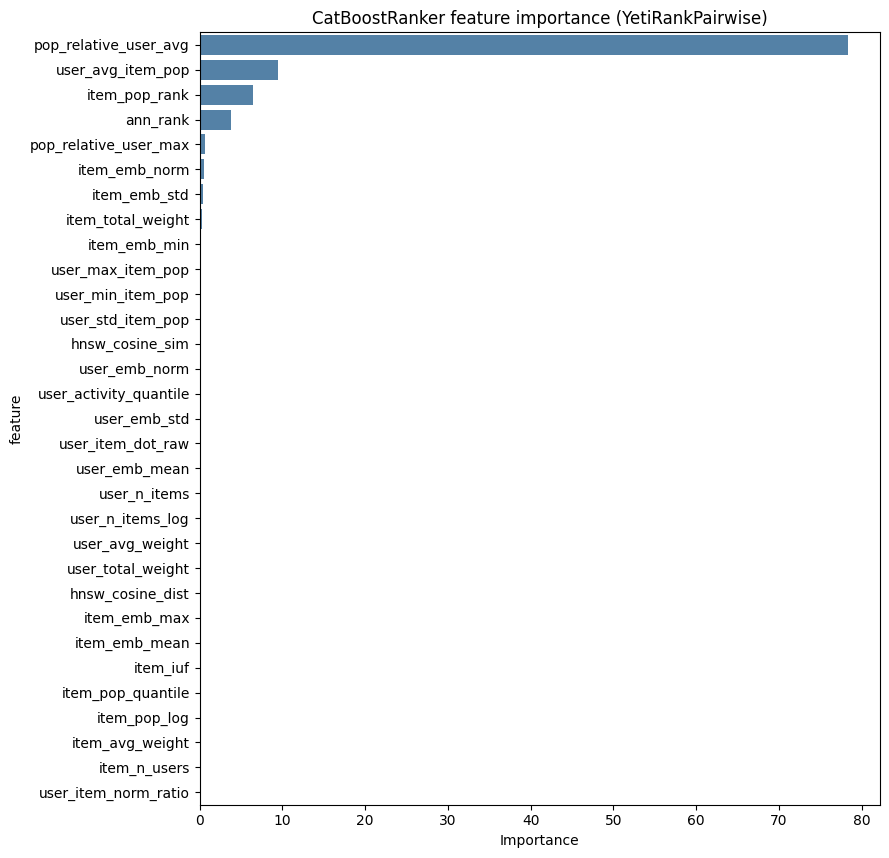

In [19]:
fi_vals = model.get_feature_importance(type='PredictionValuesChange')
fi = pd.DataFrame({'feature': FEATURE_COLS, 'importance': fi_vals})
fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)
fi.to_csv(f'{RESULTS_DIR}/feature_importance.csv', index=False)
print(fi.to_string(index=False))

plt.figure(figsize=(9, max(6, len(fi) * 0.28)))
sns.barplot(data=fi, x='importance', y='feature', color='steelblue')
plt.title('CatBoostRanker feature importance (YetiRankPairwise)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
user_state_full = compute_user_state(user_item_csr)

In [21]:
K_CAND_TEST = 200
test_uids = list(test_true.keys())
test_cands = build_candidates(
    test_uids, user_item_csr, user_state_full,
    K_CAND=K_CAND_TEST, label_dict=None,
)

for c in FEATURE_COLS:
    test_cands[c] = test_cands[c].astype(np.float32).fillna(0.0)

test_cands.to_parquet(f'{RESULTS_DIR}/test_candidates_with_features.parquet', index=False)

  ANN batch query: users=4429, k_raw=3462, max_seen=3212


In [22]:
ann_ranked_dict = {
    uid: grp.sort_values('ann_rank', ascending=True)['item_id'].tolist()
    for uid, grp in test_cands.groupby('uid')
}

def ann_only_predict(uid, R, u2id, id2it, k):
    return ann_ranked_dict.get(uid, [])[:k]

from metrics import (
    recall_at_k    as m_recall,
    precision_at_k as m_precision,
    ndcg_at_k      as m_ndcg,
    map_at_k       as m_map,
    hit_rate_at_k  as m_hit_rate,
)

ann_only_results = {}
for k in [10, 100]:
    ann_only_results[k] = dict(
        ndcg      = m_ndcg     (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_only_predict),
        recall    = m_recall   (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_only_predict),
        precision = m_precision(test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_only_predict),
        map_score = m_map      (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_only_predict),
        hit_rate  = m_hit_rate (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_only_predict),
    )

for k in [10, 100]:
    r = ann_only_results[k]
    print('ANN cosine')
    print(f'NDCG@{k}: {r["ndcg"]:.6f}')
    print(f'Recall@{k}: {r["recall"]:.6f}')
    print(f'Precision@{k}: {r["precision"]:.6f}')
    print(f'MAP@{k}: {r["map_score"]:.6f}')
    print(f'HitRate@{k}: {r["hit_rate"]:.6f}')

pd.DataFrame({
    'k': [10, 100],
    'NDCG': [ann_only_results[10]['ndcg'], ann_only_results[100]['ndcg']],
    'Recall': [ann_only_results[10]['recall'], ann_only_results[100]['recall']],
    'Precision': [ann_only_results[10]['precision'], ann_only_results[100]['precision']],
    'MAP': [ann_only_results[10]['map_score'], ann_only_results[100]['map_score']],
    'HitRate': [ann_only_results[10]['hit_rate'], ann_only_results[100]['hit_rate']],
}).to_csv(f'{RESULTS_DIR}/ann_candidate_metrics.csv', index=False)

ANN cosine
NDCG@10: 0.003311
Recall@10: 0.000720
Precision@10: 0.003048
MAP@10: 0.001071
HitRate@10: 0.028223
ANN cosine
NDCG@100: 0.005020
Recall@100: 0.006376
Precision@100: 0.002698
MAP@100: 0.000553
HitRate@100: 0.172725


In [27]:
test_cands['score'] = model.predict(test_cands[FEATURE_COLS].values)
ranked_dict = {
    uid: grp.sort_values('score', ascending=False)['item_id'].tolist()
    for uid, grp in test_cands.groupby('uid')
}

def ann_catboost_predict(uid, R, u2id, id2it, k):
    return ranked_dict.get(uid, [])[:k]

In [28]:
from metrics import (
    recall_at_k    as m_recall,
    precision_at_k as m_precision,
    ndcg_at_k      as m_ndcg,
    map_at_k       as m_map,
    hit_rate_at_k  as m_hit_rate,
)

eval_results = {}
for k in [10, 100]:
    eval_results[k] = dict(
        ndcg      = m_ndcg     (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_catboost_predict),
        recall    = m_recall   (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_catboost_predict),
        precision = m_precision(test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_catboost_predict),
        map_score = m_map      (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_catboost_predict),
        hit_rate  = m_hit_rate (test_true, user_item_matrix, user2id, id2item, k, recommend_fn=ann_catboost_predict),
    )

for k in [10, 100]:
    r = eval_results[k]
    print(f'=== ANN + CatBoostRanker (YetiRankPairwise)  @{k} ===')
    print(f'  NDCG@{k}:      {r["ndcg"]:.6f}')
    print(f'  Recall@{k}:    {r["recall"]:.6f}')
    print(f'  Precision@{k}: {r["precision"]:.6f}')
    print(f'  MAP@{k}:       {r["map_score"]:.6f}')
    print(f'  HitRate@{k}:   {r["hit_rate"]:.6f}')
    print()

=== ANN + CatBoostRanker (YetiRankPairwise)  @10 ===
  NDCG@10:      0.011332
  Recall@10:    0.002460
  Precision@10: 0.010409
  MAP@10:       0.004002
  HitRate@10:   0.085347

=== ANN + CatBoostRanker (YetiRankPairwise)  @100 ===
  NDCG@100:      0.009507
  Recall@100:    0.009663
  Precision@100: 0.004089
  MAP@100:       0.001494
  HitRate@100:   0.229849

